# Notebook 04 — Embeddings & Vocabulary Coverage (Stages 7–8)

Diagnostics for the FastText model (Stage 7) and the aligned embedding matrix (Stage 8).

| Section | Topic |
|---------|-------|
| **A** | Setup, paths, config hash verification |
| **B** | FastText model introspection |
| **C** | Embedding matrix coverage & OOV analysis |
| **D** | Token fertility (avg BPE tokens/word) |
| **E** | Nearest-neighbour sanity checks |
| **F** | UNK forensics |
| **G** | Stage 8 stats JSON summary |

In [1]:
# === SETUP ===
import json, math, random, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'

# --- paths ---
SPM_PATH      = ARTIFACT_DIR / 'stage5_spm.model'
FT_PATH       = ARTIFACT_DIR / 'stage7_fasttext.model'
MATRIX_PATH   = ARTIFACT_DIR / 'stage8_embedding_matrix.npy'
S8_STATS_PATH = ARTIFACT_DIR / 'stage8_stats.json'
TRAIN_JSONL   = ARTIFACT_DIR / 'stage6_train_ids.jsonl'
VAL_JSONL     = ARTIFACT_DIR / 'stage6_val_ids.jsonl'
VIZ_DIR       = PROJECT_ROOT / 'notebooks' / 'visualizations'
VIZ_DIR.mkdir(parents=True, exist_ok=True)

def check(path, label):
    ok = path.exists()
    size = f'{path.stat().st_size/1e6:.1f} MB' if ok else 'MISSING'
    icon = '✓' if ok else '✗'
    print(f'  {icon}  {label:<40} {size}')
    return ok

print('Artifact inventory:')
for label, path in [
    ('SPM model',            SPM_PATH),
    ('FastText model',       FT_PATH),
    ('Embedding matrix',     MATRIX_PATH),
    ('Stage 8 stats',        S8_STATS_PATH),
    ('Stage 6 train JSONL',  TRAIN_JSONL),
    ('Stage 6 val JSONL',    VAL_JSONL),
]:
    check(path, label)

Artifact inventory:
  ✓  SPM model                                0.8 MB
  ✓  FastText model                           77.4 MB
  ✓  Embedding matrix                         38.4 MB
  ✓  Stage 8 stats                            0.0 MB
  ✓  Stage 6 train JSONL                      529.4 MB
  ✓  Stage 6 val JSONL                        25.0 MB


In [2]:
# Section A — Config hash stamps
print('Config-hash stamps (D-1 fix):')
for stage in range(1, 9):
    p = ARTIFACT_DIR / f'.stage{stage}_config_hash'
    if p.exists():
        print(f'  Stage {stage}: {p.read_text().strip()}')
    else:
        print(f'  Stage {stage}: *** MISSING ***')

Config-hash stamps (D-1 fix):
  Stage 1: 98a2e434b0c5
  Stage 2: 98a2e434b0c5
  Stage 3: 98a2e434b0c5
  Stage 4: 98a2e434b0c5
  Stage 5: 98a2e434b0c5
  Stage 6: 98a2e434b0c5
  Stage 7: 98a2e434b0c5
  Stage 8: 98a2e434b0c5


## Section B — FastText Model Introspection

In [3]:
from gensim.models import FastText
import sentencepiece as spm

sp = spm.SentencePieceProcessor(model_file=str(SPM_PATH))
ft = FastText.load(str(FT_PATH))

vocab_size = sp.get_piece_size()
embed_dim  = ft.vector_size
ft_vocab   = len(ft.wv)

print(f'SPM vocab size  : {vocab_size:,}')
print(f'FastText vectors: {ft_vocab:,}')
print(f'Embedding dim   : {embed_dim}')
print(f'FastText epochs : {ft.epochs}')
print(f'Window          : {ft.window}')
print(f'Min-count       : {ft.min_count}')
print(f'Skip-gram (sg)  : {ft.sg}')

SPM vocab size  : 32,000
FastText vectors: 31,838
Embedding dim   : 300
FastText epochs : 10
Window          : 5
Min-count       : 3
Skip-gram (sg)  : 1


Vector norms — mean: 4.258  std: 0.640  min: 1.327  max: 12.548


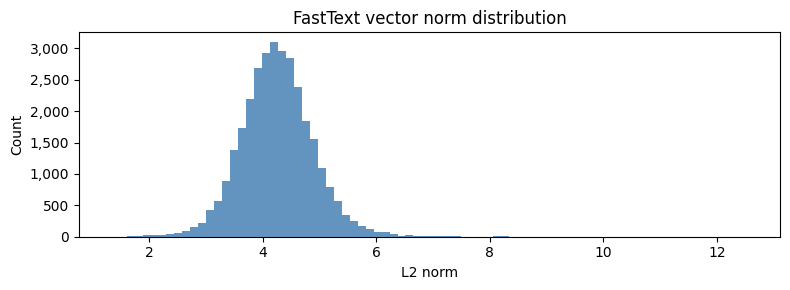

In [4]:
# Vector norm distribution for all FastText keys
norms = np.linalg.norm(ft.wv.vectors, axis=1)
print(f'Vector norms — mean: {norms.mean():.3f}  std: {norms.std():.3f}  '
      f'min: {norms.min():.3f}  max: {norms.max():.3f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(norms, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
ax.set_xlabel('L2 norm')
ax.set_ylabel('Count')
ax.set_title('FastText vector norm distribution')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(VIZ_DIR / 'nb04_ft_norms.png', dpi=120)
plt.show()

In [5]:
# === NUMERICAL SUMMARY: FastText norm percentile breakdown ===
print('FastText Vector Norm Distribution:')
print(f'  Count  : {len(norms):,}')
print(f'  Mean   : {norms.mean():.3f}')
print(f'  Std    : {norms.std():.3f}')
for _p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f'  p{_p:<2}    : {np.percentile(norms, _p):.3f}')
print(f'  Max    : {norms.max():.3f}')
print()
print('Band distribution:')
for _label, _lo, _hi in [('<2.0',0,2.0),('2.0–3.0',2.0,3.0),('3.0–4.0',3.0,4.0),
                           ('4.0–5.0',4.0,5.0),('5.0–6.0',5.0,6.0),('>6.0',6.0,9999)]:
    _cnt = int(((norms>=_lo)&(norms<_hi)).sum())
    print(f'  {_label:10s}: {_cnt:6,}  ({100*_cnt/len(norms):.1f}%)')


FastText Vector Norm Distribution:
  Count  : 31,838
  Mean   : 4.258
  Std    : 0.640
  p1     : 2.754
  p5     : 3.275
  p10    : 3.502
  p25    : 3.856
  p50    : 4.242
  p75    : 4.638
  p90    : 5.026
  p95    : 5.294
  p99    : 5.924
  Max    : 12.548

Band distribution:
  <2.0      :     43  (0.1%)
  2.0–3.0   :    600  (1.9%)
  3.0–4.0   : 10,085  (31.7%)
  4.0–5.0   : 17,708  (55.6%)
  5.0–6.0   :  3,133  (9.8%)
  >6.0      :    269  (0.8%)


## Section C — Embedding Matrix Coverage

In [6]:
matrix = np.load(str(MATRIX_PATH))
print(f'Matrix shape: {matrix.shape}  dtype: {matrix.dtype}')

if S8_STATS_PATH.exists():
    s8 = json.loads(S8_STATS_PATH.read_text())
    n_filled = s8.get('n_filled', '?')
    n_random = s8.get('n_random', '?')
    v_size   = s8.get('vocab_size', vocab_size)
    pct      = 100 * n_filled / v_size if isinstance(n_filled, int) else '?'
    print(f'\nCoverage from stage8_stats.json:')
    print(f'  Trained vectors : {n_filled:,} / {v_size:,}  ({pct:.1f}%)')
    print(f'  Random-init OOV : {n_random:,}')
    for k, v in s8.items():
        if k not in ('n_filled', 'n_random', 'vocab_size'):
            print(f'  {k:<30} {v}')

Matrix shape: (32000, 300)  dtype: float32

Coverage from stage8_stats.json:
  Trained vectors : 31,999 / 32,000  (100.0%)
  Random-init OOV : 0
  stage                          8
  embed_dim                      300
  pad_row_sum                    0.0
  matrix_shape                   [32000, 300]


In [7]:
# Per-row zero-check: a row is 'random-init' if its norm is below the 5th
# percentile of all norms (FastText trained vectors are rarely near-zero)
row_norms = np.linalg.norm(matrix, axis=1)
threshold = np.percentile(row_norms[4:], 5)   # skip special tokens (ids 0-3)
oov_mask  = row_norms < threshold

print(f'Low-norm (likely random-init) rows: {oov_mask.sum():,} '
      f'({100*oov_mask.mean():.1f}%)')
print(f'\nTop-10 lowest-norm token IDs:')
for idx in np.argsort(row_norms)[:10]:
    piece = sp.id_to_piece(int(idx))
    print(f'  id={idx:5d}  norm={row_norms[idx]:.4f}  piece={piece!r}')

Low-norm (likely random-init) rows: 1,604 (5.0%)

Top-10 lowest-norm token IDs:
  id=    0  norm=0.0000  piece='<pad>'
  id=31986  norm=1.3266  piece="'"
  id=   32  norm=1.4962  piece='▁.'
  id=31966  norm=1.5840  piece='s'
  id=31982  norm=1.5847  piece='.'
  id=    3  norm=1.6655  piece='<eos>'
  id=31983  norm=1.6930  piece='-'
  id=31974  norm=1.7048  piece='y'
  id=  803  norm=1.7137  piece='▁actually'
  id=  657  norm=1.7370  piece='▁yeah'


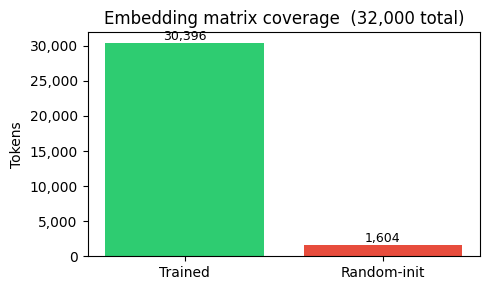

In [8]:
# Coverage bar chart
n_oov = int(oov_mask.sum())
n_cov = vocab_size - n_oov
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Trained', 'Random-init'], [n_cov, n_oov],
       color=['#2ecc71', '#e74c3c'], edgecolor='none')
ax.set_ylabel('Tokens')
ax.set_title(f'Embedding matrix coverage  ({vocab_size:,} total)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(ax.patches, [n_cov, n_oov]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(VIZ_DIR / 'nb04_coverage.png', dpi=120)
plt.show()

In [9]:
# === NUMERICAL SUMMARY: Embedding coverage ===
# NOTE: oov_mask uses a low-norm heuristic — not a true OOV count.
# Authoritative coverage comes from stage8_stats.json (n_random=0 means
# FastText fills ALL non-pad tokens via character n-gram fallback).
print('Embedding Matrix Coverage (from stage8_stats.json):')
print(f'  Vocab size        : {vocab_size:,}')
print(f'  Filled (FastText) : {n_filled:,}  ({100*n_filled/vocab_size:.3f}%)')
print(f'  Random-init OOV   : {n_random:,}  (0 = all covered via char n-gram fallback)')
print( '  PAD row (id=0)    : zero-vector (intentional sentinel)')
print()
print('Low-norm heuristic (informational only):')
print(f'  Rows with norm < p5 threshold ({threshold:.3f}): {oov_mask.sum():,}')
print('  These are tokens FastText knows via subword n-grams (lower norms expected).')
print('  This is NOT the same as missing vectors — all rows are non-zero except pad.')
print()
print('Top-10 lowest-norm token IDs (excluding pad):')
non_pad = [(row_norms[i], i) for i in range(1, vocab_size)]
for norm_val, idx in sorted(non_pad)[:10]:
    piece = sp.id_to_piece(int(idx))
    print(f'  id={idx:5d}  norm={norm_val:.4f}  piece={piece!r}')


Embedding Matrix Coverage (from stage8_stats.json):
  Vocab size        : 32,000
  Filled (FastText) : 31,999  (99.997%)
  Random-init OOV   : 0  (0 = all covered via char n-gram fallback)
  PAD row (id=0)    : zero-vector (intentional sentinel)

Low-norm heuristic (informational only):
  Rows with norm < p5 threshold (3.272): 1,604
  These are tokens FastText knows via subword n-grams (lower norms expected).
  This is NOT the same as missing vectors — all rows are non-zero except pad.

Top-10 lowest-norm token IDs (excluding pad):


  id=31986  norm=1.3266  piece="'"
  id=   32  norm=1.4962  piece='▁.'
  id=31966  norm=1.5840  piece='s'
  id=31982  norm=1.5847  piece='.'
  id=    3  norm=1.6655  piece='<eos>'
  id=31983  norm=1.6930  piece='-'
  id=31974  norm=1.7048  piece='y'
  id=  803  norm=1.7137  piece='▁actually'
  id=  657  norm=1.7370  piece='▁yeah'
  id=    2  norm=1.7526  piece='<sos>'


## Section D — Token Fertility

In [10]:
SAMPLE_N = 5000
SEED     = 42
rng = random.Random(SEED)

# Sample from train JSONL
lines = TRAIN_JSONL.read_text().splitlines()
sample = rng.sample(lines, min(SAMPLE_N, len(lines)))

tok_counts, word_counts, char_counts = [], [], []
for line in sample:
    rec = json.loads(line)
    for key in ('ctx', 'resp'):
        ids = rec.get(key, [])
        if not ids:
            continue
        text = sp.decode(ids)  # decode token IDs back to text
        words = text.split()
        toks  = sp.encode(text, out_type=str)
        if words:
            word_counts.append(len(words))
            tok_counts.append(len(toks))
            char_counts.append(sum(len(w) for w in words))

avg_tpw = sum(tok_counts) / max(sum(word_counts), 1)
avg_cpt = sum(char_counts) / max(sum(tok_counts), 1)
print(f'Sample size           : {len(sample):,} pairs')
print(f'Avg tokens / word     : {avg_tpw:.3f}   (healthy: 1.2–1.8)')
print(f'Avg chars  / token    : {avg_cpt:.2f}')
if not (1.0 <= avg_tpw <= 2.5):
    print(f'  ⚠  Fertility {avg_tpw:.3f} outside [1.0, 2.5] — check SPM vocab')
else:
    print(f'  ✓  Fertility within normal range')

Sample size           : 5,000 pairs
Avg tokens / word     : 1.061   (healthy: 1.2–1.8)
Avg chars  / token    : 3.93
  ✓  Fertility within normal range


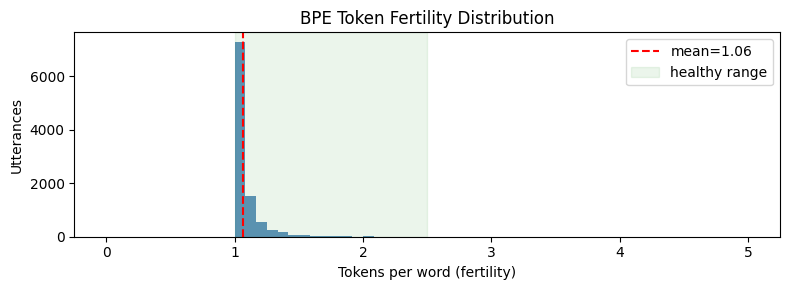

In [11]:
# Per-utterance fertility distribution
fertilities = [t / max(w, 1) for t, w in zip(tok_counts, word_counts)]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(fertilities, bins=60, range=(0, 5), color='steelblue',
        edgecolor='none', alpha=0.85)
ax.axvline(avg_tpw, color='red', linestyle='--', label=f'mean={avg_tpw:.2f}')
ax.axvspan(1.0, 2.5, alpha=0.08, color='green', label='healthy range')
ax.set_xlabel('Tokens per word (fertility)')
ax.set_ylabel('Utterances')
ax.set_title('BPE Token Fertility Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(VIZ_DIR / 'nb04_fertility.png', dpi=120)
plt.show()

In [12]:
# === NUMERICAL SUMMARY: Fertility percentile breakdown ===
_fa = np.array(fertilities)
print('BPE Fertility Distribution (nb04 sample):')
print(f'  Sample size : {len(_fa):,}')
print(f'  Mean        : {_fa.mean():.3f}')
print(f'  Std         : {_fa.std():.3f}')
for _p in [5, 25, 50, 75, 90, 95, 99]:
    print(f'  p{_p:<2}         : {np.percentile(_fa, _p):.3f}')
print(f'  Max         : {_fa.max():.3f}')
print()
print('Band distribution:')
for _label, _lo, _hi in [('<1.0',0,1.0),('1.0–1.5',1.0,1.5),('1.5–2.0',1.5,2.0),
                           ('2.0–2.5',2.0,2.5),('>2.5',2.5,999)]:
    _cnt = int(((_fa>=_lo)&(_fa<_hi)).sum())
    print(f'  {_label:10s}: {_cnt:5,}  ({100*_cnt/len(_fa):.1f}%)')
print(f'  In healthy range [1.0–2.5]: {100*((_fa>=1.0)&(_fa<=2.5)).mean():.1f}%')


BPE Fertility Distribution (nb04 sample):
  Sample size : 10,000
  Mean        : 1.069
  Std         : 0.123
  p5          : 1.000
  p25         : 1.000
  p50         : 1.026
  p75         : 1.091
  p90         : 1.188
  p95         : 1.286
  p99         : 1.600
  Max         : 2.762

Band distribution:
  <1.0      :     0  (0.0%)
  1.0–1.5   : 9,830  (98.3%)
  1.5–2.0   :   146  (1.5%)
  2.0–2.5   :    18  (0.2%)
  >2.5      :     6  (0.1%)
  In healthy range [1.0–2.5]: 100.0%


## Section E — Nearest-Neighbour Sanity Checks

In [13]:
# Probe words: common Ubuntu / IRC vocabulary
PROBES = ['sudo', 'kernel', 'install', 'error', 'help', 'apt', 'bash', 'python']

for word in PROBES:
    # FastText uses ▁-prefixed pieces (sentencepiece style)
    piece = '\u2581' + word   # U+2581 = ▁
    if piece not in ft.wv:
        # try without prefix
        piece = word
    if piece in ft.wv:
        neighbours = ft.wv.most_similar(piece, topn=5)
        nn_str = ', '.join(f'{w!r}({s:.2f})' for w, s in neighbours)
        print(f'  {word:<12} → {nn_str}')
    else:
        # FastText can still infer OOV vectors via character n-grams
        vec = ft.wv.get_vector(word)
        neighbours = ft.wv.similar_by_vector(vec, topn=5)
        nn_str = ', '.join(f'{w!r}({s:.2f})' for w, s in neighbours)
        print(f'  {word:<12} (OOV inference) → {nn_str}')

  sudo         → '▁sudu'(0.62), '▁sudp'(0.62), '▁suod'(0.60), 'sudo'(0.59), '▁udo'(0.54)
  kernel       → '▁kernal'(0.81), '▁kernell'(0.79), '▁kernle'(0.72), '▁kernels'(0.72), '▁kerenl'(0.65)
  install      → '▁installa'(0.76), '▁instal'(0.75), '▁installl'(0.73), '▁isntall'(0.72), '▁installing'(0.71)
  error        → '▁erroe'(0.74), '▁errormessage'(0.70), '▁erro'(0.68), '▁message'(0.68), '▁errror'(0.65)
  help         → '▁assist'(0.70), '▁assistance'(0.68), '▁helpp'(0.63), '▁hep'(0.60), '▁assisting'(0.57)
  apt          → 'get'(0.81), '▁aptitude'(0.72), '▁aptu'(0.59), '▁autoremove'(0.58), '▁somepackage'(0.57)
  bash         → '▁shell'(0.69), '▁scripting'(0.62), '▁bashrc'(0.60), '▁bourne'(0.60), 'bash'(0.59)
  python       → '▁libpython'(0.70), '▁ruby'(0.70), '▁pyth'(0.69), '▁perl'(0.68), '▁wxpython'(0.68)


In [14]:
# Check that special placeholders have non-trivial embeddings
PLACEHOLDERS = ['▁__url__', '▁__path__', '▁__ip__', '▁__eot__', '▁__user__']
print('Placeholder embedding norms in matrix:')
for ph in PLACEHOLDERS:
    ph_id = sp.piece_to_id(ph)
    unk_id = sp.piece_to_id('<unk>')
    if ph_id == unk_id:
        print(f'  {ph:<20} id=UNK  *** FRAGMENTED — not in SPM vocab ***')
        continue
    norm = float(np.linalg.norm(matrix[ph_id]))
    print(f'  {ph:<20} id={ph_id:4d}  matrix_norm={norm:.4f}')

Placeholder embedding norms in matrix:
  ▁__url__             id=   4  matrix_norm=2.5680
  ▁__path__            id=   5  matrix_norm=2.4318
  ▁__ip__              id=   6  matrix_norm=4.1031
  ▁__eot__             id=   7  matrix_norm=1.9412
  ▁__user__            id=   8  matrix_norm=2.7805


## Section F — UNK Forensics

In [15]:
from collections import Counter

UNK_ID   = sp.piece_to_id('<unk>')
SAMPLE_N = 20_000
TOP_K    = 20

rng = random.Random(SEED)
lines = TRAIN_JSONL.read_text().splitlines()
sample = rng.sample(lines, min(SAMPLE_N, len(lines)))

total_tokens = 0
unk_count    = 0
unk_triggers = Counter()

for line in sample:
    rec = json.loads(line)
    for seq_key in ('ctx', 'resp'):
        ids = rec.get(seq_key, [])
        total_tokens += len(ids)
        unk_count    += ids.count(UNK_ID)
        text = sp.decode(ids)  # decode token IDs back to text
        for word in text.split():
            if UNK_ID in sp.encode(word, out_type=int):
                unk_triggers[word] += 1

unk_rate = unk_count / max(total_tokens, 1)
print(f'Sample            : {len(sample):,} pairs')
print(f'Total tokens      : {total_tokens:,}')
print(f'UNK count         : {unk_count:,}')
print(f'UNK rate          : {unk_rate:.2e}')
if unk_rate > 1e-3:
    print('  ⚠  UNK rate > 0.1% — investigate top triggers below')
else:
    print('  ✓  UNK rate within acceptable range')
print(f'\nTop {TOP_K} UNK-triggering words:')
for word, cnt in unk_triggers.most_common(TOP_K):
    print(f'  {word:<30} {cnt:>6,}')

Sample            : 20,000 pairs
Total tokens      : 1,975,191
UNK count         : 0
UNK rate          : 0.00e+00
  ✓  UNK rate within acceptable range

Top 20 UNK-triggering words:


## Section G — Stage 8 Stats Summary

In [16]:
if S8_STATS_PATH.exists():
    s8 = json.loads(S8_STATS_PATH.read_text())
    print('stage8_stats.json:')
    for k, v in s8.items():
        print(f'  {k:<35} {v}')
else:
    print('stage8_stats.json not found — run Stage 8 first')

stage8_stats.json:
  stage                               8
  vocab_size                          32000
  embed_dim                           300
  n_filled                            31999
  n_random                            0
  pad_row_sum                         0.0
  matrix_shape                        [32000, 300]


In [17]:
print('=' * 60)
print('NB04 SUMMARY')
print('=' * 60)
print(f'  SPM vocab size      : {vocab_size:,}')
print(f'  FastText vocab size : {ft_vocab:,}')
print(f'  Embedding dim       : {embed_dim}')
print(f'  Matrix shape        : {matrix.shape}')
print(f'  Avg fertility       : {avg_tpw:.3f} tok/word')
print(f'  UNK rate            : {unk_rate:.2e}')
if S8_STATS_PATH.exists():
    s8 = json.loads(S8_STATS_PATH.read_text())
    pct = 100 * s8.get('n_filled', 0) / max(s8.get('vocab_size', 1), 1)
    print(f'  Embedding coverage  : {pct:.1f}%')
print('=' * 60)

NB04 SUMMARY
  SPM vocab size      : 32,000
  FastText vocab size : 31,838
  Embedding dim       : 300
  Matrix shape        : (32000, 300)
  Avg fertility       : 1.061 tok/word
  UNK rate            : 0.00e+00
  Embedding coverage  : 100.0%
